### Imports & device

In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# GPU / CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))


Using device: cpu


###  Data paths & folders

In [2]:
MAIN_DIR = r"C:\\temp\\KWS\data\speech-commands-v2"

# List all subfolders inside the dataset directory
folders = [f for f in os.listdir(MAIN_DIR)
           if os.path.isdir(os.path.join(MAIN_DIR, f))]
print("All folders:", folders)

# Select 7 words (example: folders 13 to 20)
subset_folders = folders[13:20]
print("Selected folders:", subset_folders)


All folders: ['backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'visual', 'wow', 'yes', 'zero', '_background_noise_']
Selected folders: ['house', 'learn', 'left', 'marvin', 'nine', 'no', 'off']


### Load Audio Files + Parallel Processing

In [3]:
import multiprocessing.dummy as mp

sampling_rate = 16000

def load_audio(file_path):
    """
    Load a single WAV file.
    Returns:
        filename: the file name only
        label: the folder name (the class)
        y: the raw audio signal
    """
    y, sr = librosa.load(file_path, sr=sampling_rate)
    label = os.path.basename(os.path.dirname(file_path))
    filename = os.path.basename(file_path)
    return filename, label, y

# Collect all WAV file paths from the selected folders
file_paths = []
for folder in subset_folders:
    folder_dir = os.path.join(MAIN_DIR, folder)
    files = [os.path.join(folder_dir, f)
             for f in os.listdir(folder_dir)
             if f.endswith(".wav")]
    file_paths.extend(files)

print("Total wav files:", len(file_paths))

# Load files in parallel for faster preprocessing
with mp.Pool(os.cpu_count()) as pool:
    audio_data = pool.map(load_audio, file_paths)

# Store everything in a clean DataFrame
audio_df = pd.DataFrame(audio_data,
                        columns=["filename", "label", "audio_data"])
print(audio_df.shape)
audio_df.head()


Total wav files: 21209
(21209, 3)


,filename,label,audio_data
0,00970ce1_nohash_0.wav,house,"[0.001373291, 0.0015869141, 0.0011901855, 0.00..."
1,00b01445_nohash_0.wav,house,"[0.0010375977, 6.1035156e-05, -0.00091552734, ..."
2,00b01445_nohash_1.wav,house,"[-0.0019226074, -0.0010375977, -0.0006713867, ..."
3,00b01445_nohash_2.wav,house,"[-0.0010070801, -0.001373291, 0.0032348633, 0...."
4,012187a4_nohash_0.wav,house,"[9.1552734e-05, 0.0, -0.00033569336, -0.000122..."


### Extract MFCC features (parallel)

In [4]:
def extract_mfcc_parallel(audio_data, sr, n_mfcc=13):
    """
    Extract MFCC features from a single audio waveform.
    Returns a matrix of shape (Time, n_mfcc).
    """
    return librosa.feature.mfcc(y=audio_data, sr=sr, n_mfcc=n_mfcc).T

# Convert the audio column into a Python list
audio_data_list = audio_df["audio_data"].tolist()
# Prepare list of tasks: (audio_signal, sampling_rate)
tasks = [(audio, sampling_rate) for audio in audio_data_list]

# Add MFCC results back into the dataframe
with mp.Pool(os.cpu_count()) as pool:
    mfcc_features = list(
        tqdm(
            pool.starmap(extract_mfcc_parallel, tasks),
            total=len(tasks),
            desc="Extracting MFCCs"
        )
    )

# Add MFCC results back into the dataframe
audio_df["mfcc"] = mfcc_features

audio_df.head()


Extracting MFCCs: 100%|██████████| 21209/21209 [00:00<00:00, 4236450.78it/s]


,filename,label,audio_data,mfcc
0,00970ce1_nohash_0.wav,house,"[0.001373291, 0.0015869141, 0.0011901855, 0.00...","[[-548.69867, 48.93126, 15.867992, 8.24266, -4..."
1,00b01445_nohash_0.wav,house,"[0.0010375977, 6.1035156e-05, -0.00091552734, ...","[[-457.87564, 28.71679, -23.402252, 8.10243, -..."
2,00b01445_nohash_1.wav,house,"[-0.0019226074, -0.0010375977, -0.0006713867, ...","[[-452.73114, 4.716221, -21.18306, -4.780823, ..."
3,00b01445_nohash_2.wav,house,"[-0.0010070801, -0.001373291, 0.0032348633, 0....","[[-471.46115, -21.240509, -8.912944, 18.826454..."
4,012187a4_nohash_0.wav,house,"[9.1552734e-05, 0.0, -0.00033569336, -0.000122...","[[-670.3497, 45.363186, 0.90775144, 8.009051, ..."


### Scale MFCC features

In [5]:
# Concatenate all MFCC matrices from all audio samples into one big matrix
mfcc_flattened = np.concatenate(audio_df["mfcc"].values, axis=0)
print("Flattened MFCC shape:", mfcc_flattened.shape)

# Learns the mean and std for each MFCC coefficient dimension
scaler = StandardScaler().fit(mfcc_flattened)

def scale_features(features, scaler):
    """
    Apply the fitted scaler to each MFCC sample.
    Each feature is a matrix of shape (T, F) where:
        T = number of time frames (varies per sample)
        F = number of MFCC coefficients (usually 13)
    """
    scaled_features = []
    for feature in features:
         # Standardize each matrix: (feature - mean) / std
        scaled = scaler.transform(feature)   # T × F
        scaled_features.append(scaled.astype(np.float32))
    return np.array(scaled_features, dtype=object)

audio_df["scaled_mfcc"] = scale_features(audio_df["mfcc"].values, scaler)
audio_df.head()


Flattened MFCC shape: (666144, 13)


,filename,label,audio_data,mfcc,scaled_mfcc
0,00970ce1_nohash_0.wav,house,"[0.001373291, 0.0015869141, 0.0011901855, 0.00...","[[-548.69867, 48.93126, 15.867992, 8.24266, -4...","[[-0.92448574, -0.60266566, 0.5252973, -0.1816..."
1,00b01445_nohash_0.wav,house,"[0.0010375977, 6.1035156e-05, -0.00091552734, ...","[[-457.87564, 28.71679, -23.402252, 8.10243, -...","[[-0.39358974, -0.92295533, -0.44296402, -0.18..."
2,00b01445_nohash_1.wav,house,"[-0.0019226074, -0.0010375977, -0.0006713867, ...","[[-452.73114, 4.716221, -21.18306, -4.780823, ...","[[-0.36351812, -1.3032342, -0.3882468, -0.6608..."
3,00b01445_nohash_2.wav,house,"[-0.0010070801, -0.001373291, 0.0032348633, 0....","[[-471.46115, -21.240509, -8.912944, 18.826454...","[[-0.4730023, -1.7145076, -0.08571043, 0.20770..."
4,012187a4_nohash_0.wav,house,"[9.1552734e-05, 0.0, -0.00033569336, -0.000122...","[[-670.3497, 45.363186, 0.90775144, 8.009051, ...","[[-1.6355832, -0.65920025, 0.15643217, -0.1902..."


###  Visualization of one sample

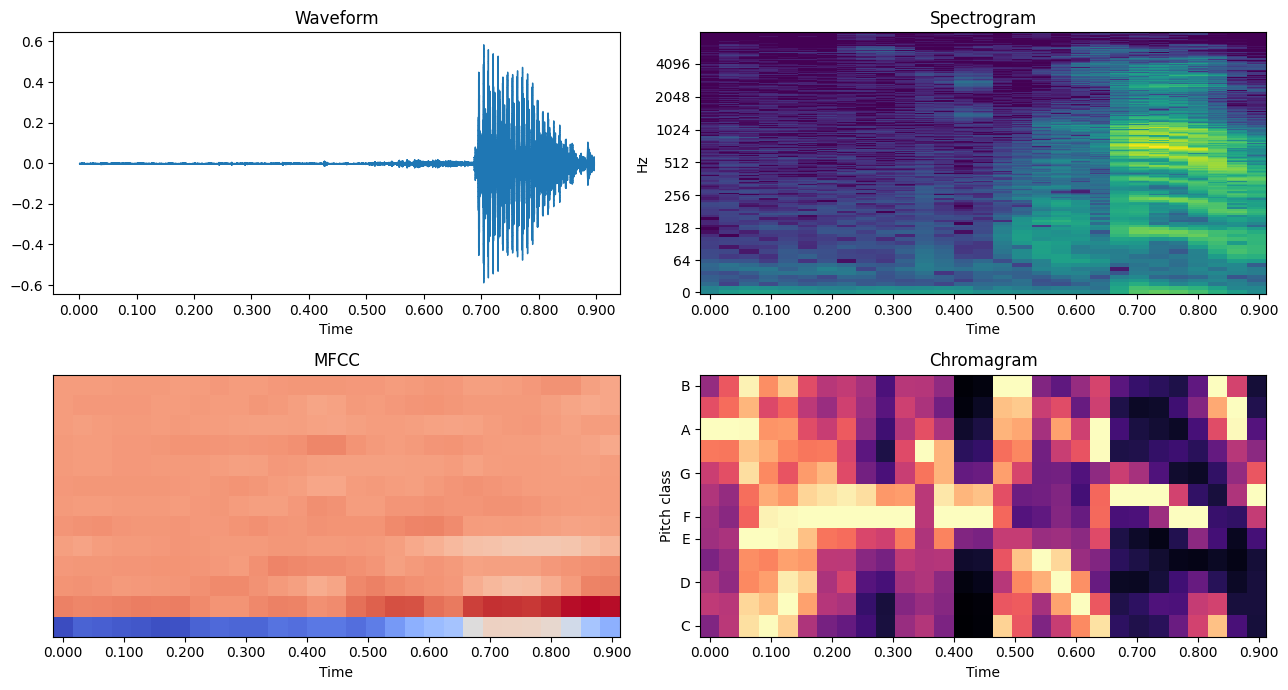

In [6]:
audio_sample = audio_df[audio_df["label"] == audio_df["label"].unique()[0]]["audio_data"].iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# Waveform
librosa.display.waveshow(audio_sample, sr=sampling_rate, ax=axes[0, 0])
axes[0, 0].set_title("Waveform")

# Spectrogram
D = librosa.amplitude_to_db(np.abs(librosa.stft(audio_sample)), ref=np.max)
librosa.display.specshow(D, sr=sampling_rate, x_axis="time", y_axis="log",
                         ax=axes[0, 1], cmap="viridis")
axes[0, 1].set_title("Spectrogram")

# MFCC
mfccs = librosa.feature.mfcc(y=audio_sample, sr=sampling_rate, n_mfcc=13)
librosa.display.specshow(mfccs, x_axis="time", sr=sampling_rate, ax=axes[1, 0])
axes[1, 0].set_title("MFCC")

# Chromagram
chroma = librosa.feature.chroma_stft(y=audio_sample, sr=sampling_rate)
librosa.display.specshow(chroma, y_axis="chroma", x_axis="time",
                         sr=sampling_rate, ax=axes[1, 1])
axes[1, 1].set_title("Chromagram")

plt.tight_layout()
plt.show()


### Split, pad and build DataLoaders

In [7]:
# Extract features (MFCC matrices), labels, filenames
X_all = audio_df["scaled_mfcc"].values
y_all = audio_df["label"].values
fn_all = audio_df["filename"].values

# Split into train + temp (val+test)
X_train, X_temp, y_train, y_temp, fn_train, fn_temp= train_test_split(
    X_all, y_all, fn_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

# Split temp into validation and test sets
X_val, X_test, y_val, y_test , fn_val, fn_test = train_test_split(
    X_temp, y_temp, fn_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(len(X_train), len(X_val), len(X_test))

# Save the validation file names as a global change later
val_filenames = fn_val

def pad_mfcc_list(mfcc_list, max_len=None):
    """
    Pads all MFCC matrices to the same time dimension (max_len).
    mfcc_list: list of matrices shaped (T_i, F)
    Returns: array shaped (N, max_len, F)
    """
    if max_len is None:
        max_len = max(m.shape[0] for m in mfcc_list)
    # If no length provided, use the longest sequence
    n_samples = len(mfcc_list)
    n_features = mfcc_list[0].shape[1] # Initialize output tensor with zeros
    # Initialize output tensor with zeros
    X_padded = np.zeros((n_samples, max_len, n_features), dtype=np.float32)
    # Copy each MFCC matrix into padded container
    for i, m in enumerate(mfcc_list):
        length = m.shape[0]
        X_padded[i, :length, :] = m
    return X_padded

# Determine maximum time length across all MFCC matrices
global_max_len = max(m.shape[0] for m in X_all)
# Apply padding to train/validation/test
X_train_padded = pad_mfcc_list(X_train, max_len=global_max_len)
X_val_padded   = pad_mfcc_list(X_val,   max_len=global_max_len)
X_test_padded  = pad_mfcc_list(X_test,  max_len=global_max_len)

print("Train padded shape:", X_train_padded.shape)

# Label encoding (word -> number)
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc   = label_encoder.transform(y_val)
y_test_enc  = label_encoder.transform(y_test)

print("Classes:", list(label_encoder.classes_))
num_classes = len(label_encoder.classes_)

# Dataset
class MFCCDataset(Dataset):
    """
    A PyTorch dataset for padded MFCC sequences.
    Input shape per sample: (1, T, F)
    """
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).unsqueeze(1)  # (N, 1, T, F)
        self.y = torch.from_numpy(y).long()
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Dataset objects
train_dataset = MFCCDataset(X_train_padded, y_train_enc)
val_dataset   = MFCCDataset(X_val_padded,   y_val_enc)
test_dataset  = MFCCDataset(X_test_padded,  y_test_enc)

# DataLoaders (shuffle)
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)


16967 2121 2121
Train padded shape: (16967, 32, 13)
Classes: ['house', 'learn', 'left', 'marvin', 'nine', 'no', 'off']


### Basic DSCNN model

In [8]:
class BasicDSCNN(nn.Module):
    def __init__(self, num_classes):
        super(BasicDSCNN, self).__init__()

        # Standard 2D convolution (feature extractor starter)
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(64)
        # Depthwise convolution (separate filter per channel)
        # Each channel has its own filter → no mixing between channels
        self.dw2   = nn.Conv2d(64, 64, kernel_size=3, padding=1, groups=64)
        self.bn2   = nn.BatchNorm2d(64)
        # Pointwise convolution (1x1) — mixes channels after depthwise
        self.pw2   = nn.Conv2d(64, 64, kernel_size=1)
        self.bn3   = nn.BatchNorm2d(64)
        # Downsampling to reduce feature map size
        self.pool2 = nn.MaxPool2d(2)

        # Second Depthwise + Pointwise block
        self.dw3   = nn.Conv2d(64, 64, kernel_size=3, padding=1, groups=64)
        self.bn4   = nn.BatchNorm2d(64)
        self.pw3   = nn.Conv2d(64, 128, kernel_size=1)
        self.bn5   = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2)

        # Global Average Pooling — converts feature map into one vector
        self.gap   = nn.AdaptiveAvgPool2d(1)

        # Final classifier (Logits vector which goes to softmax)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x):
        # Initial conv
        x = F.relu(self.bn1(self.conv1(x)))

        # Block 1: Depthwise + Pointwise
        x = F.relu(self.bn2(self.dw2(x)))
        x = F.relu(self.bn3(self.pw2(x)))
        x = self.pool2(x)  # downsample

        # Block 2: Depthwise + Pointwise
        x = F.relu(self.bn4(self.dw3(x)))
        x = F.relu(self.bn5(self.pw3(x)))
        x = self.pool3(x)  # downsample

        # Pool to a single vector
        x = self.gap(x)
        x = torch.flatten(x, 1)

        # Output layer
        x = self.fc_out(x)
        return x


### Improved DSCNN model

In [9]:
class ImprovedDSCNN(nn.Module):
    def __init__(self, num_classes):
        super(ImprovedDSCNN, self).__init__()

        # Initial conv + batch norm (same as Basic)s
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(64)

        # Block 1: Depthwise + Pointwise + MaxPool + Dropout
        self.dw2   = nn.Conv2d(64, 64, kernel_size=3, padding=1, groups=64)
        self.bn2   = nn.BatchNorm2d(64)
        self.pw2   = nn.Conv2d(64, 64, kernel_size=1)
        self.bn3   = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2)
        self.drop2 = nn.Dropout(0.3) # regularization

        # Block 2: Depthwise + Pointwise + MaxPool + Dropout
        self.dw3   = nn.Conv2d(64, 64, kernel_size=3, padding=1, groups=64)
        self.bn4   = nn.BatchNorm2d(64)
        self.pw3   = nn.Conv2d(64, 128, kernel_size=1)
        self.bn5   = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2)
        self.drop3 = nn.Dropout(0.3)

        # Global Average Pooling
        self.gap   = nn.AdaptiveAvgPool2d(1)

        # Extra fully-connected layer for more capacity + dropout
        self.fc1   = nn.Linear(128, 128)
        self.drop_fc = nn.Dropout(0.5)
        self.fc_out  = nn.Linear(128, num_classes)

    def forward(self, x):
        # Input: (B, 1, T, F)
        x = F.relu(self.bn1(self.conv1(x)))

        x = F.relu(self.bn2(self.dw2(x)))
        x = F.relu(self.bn3(self.pw2(x)))
        x = self.pool2(x)
        x = self.drop2(x)

        x = F.relu(self.bn4(self.dw3(x)))
        x = F.relu(self.bn5(self.pw3(x)))
        x = self.pool3(x)
        x = self.drop3(x)

        x = self.gap(x)
        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.drop_fc(x)
        x = self.fc_out(x)
        return x


### Generic train/eval utilities

In [10]:
# Loss Function, gets output and y_batch(real labels)
criterion = nn.CrossEntropyLoss()

def train_model(model, train_loader, val_loader,
                num_epochs=150, patience=10,
                lr=1e-3, weight_decay=1e-3,
                model_name="model"):
    """
    Train a given model with train/validation loaders,
    using early stopping based on validation accuracy.
    """
    # Move model to CPU/GPU
    model = model.to(device)

    # Adam optimizer with L2 regularization (weight_decay)
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=lr,
                                 weight_decay=weight_decay)

    best_val_acc = 0.0
    epochs_no_improve = 0
    best_path = f"best_{model_name}.pt" # file to save best weights

    # History lists for plotting later
    train_loss_hist, val_loss_hist = [], []
    train_acc_hist,  val_acc_hist  = [], []

    # Main training loop over epochs 
    for epoch in range(1, num_epochs + 1):
        # --- Train ---
        model.train() # enable dropout/batchnorm in training mode
        running_loss, correct, total = 0.0, 0, 0
        # Iterate over mini-batches from train_loader
        for X_batch, y_batch in train_loader:
            # Move batch to device
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            # Reset gradients from previous step
            optimizer.zero_grad()
            # Forward pass: MFCC->layers->model prediction
            outputs = model(X_batch)
            # Compute loss for this batch
            loss = criterion(outputs, y_batch)
            # Backward pass: compute gradients
            loss.backward()
            # Update weights
            optimizer.step()

            # Loss and accuracy statistics
            running_loss += loss.item() * X_batch.size(0)
            _, preds = torch.max(outputs, 1) # class with max score
            total += y_batch.size(0)
            correct += (preds == y_batch).sum().item()

        # Average train loss and accuracy over all training samples
        train_loss = running_loss / total
        train_acc  = correct / total

        # --- Validation ---
        model.eval() # evaluation mode (no dropout, batchnorm in eval mode)

        val_running_loss, val_correct, val_total = 0.0, 0, 0

        # Disable gradient computation during validation
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                # Forward
                outputs = model(X_batch)
                # Compute validation loss
                loss = criterion(outputs, y_batch)
                # Compute validation accuracy
                val_running_loss += loss.item() * X_batch.size(0)
                _, preds = torch.max(outputs, 1)
                val_total += y_batch.size(0)
                val_correct += (preds == y_batch).sum().item()

        # Average validation loss & accuracy        
        val_loss = val_running_loss / val_total
        val_acc  = val_correct / val_total

        # Store history for plotting
        train_loss_hist.append(train_loss)
        val_loss_hist.append(val_loss)
        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)

        print(f"Epoch {epoch:3d}/{num_epochs} | "
              f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
              f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")

        # Early stopping based on validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), best_path)
            print("  → New best model saved!")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping triggered.")
                break

    history = {
        "train_loss": train_loss_hist,
        "val_loss":   val_loss_hist,
        "train_acc":  train_acc_hist,
        "val_acc":    val_acc_hist,
        "best_path":  best_path,
        "best_val_acc": best_val_acc
    }
    return history

def evaluate_model(model_class, best_path, loader, model_name="model"):
    """
    Load a saved model and evaluate it on a given DataLoader.
    """
    # Re-create model architecture and load best weights
    model = model_class(num_classes).to(device)
    model.load_state_dict(torch.load(best_path, map_location=device))
    model.eval()

    total, correct, running_loss = 0, 0, 0.0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_loss += loss.item() * X_batch.size(0)
            _, preds = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (preds == y_batch).sum().item()

    loss = running_loss / total
    acc  = correct / total
    print(f"[{model_name}] Loss: {loss:.4f}, Accuracy: {acc:.4f}")
    return model

def plot_history(history, title_prefix=""):
    epochs_range = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history["train_loss"], "bo-", label="Training Loss")
    plt.plot(epochs_range, history["val_loss"],   "r*-", label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} Training and Validation Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history["train_acc"], "bo-", label="Training Accuracy")
    plt.plot(epochs_range, history["val_acc"],   "r*-", label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} Training and Validation Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


### Train BasicDSCNN (first model)

Epoch   1/150 | Train loss: 1.1454, acc: 0.6494 | Val loss: 0.6914, acc: 0.7911
  → New best model saved!
Epoch   2/150 | Train loss: 0.5032, acc: 0.8559 | Val loss: 0.4532, acc: 0.8713
  → New best model saved!
Epoch   3/150 | Train loss: 0.3501, acc: 0.8972 | Val loss: 0.3453, acc: 0.8996
  → New best model saved!
Epoch   4/150 | Train loss: 0.2779, acc: 0.9180 | Val loss: 0.2919, acc: 0.9118
  → New best model saved!
Epoch   5/150 | Train loss: 0.2373, acc: 0.9285 | Val loss: 0.2733, acc: 0.9161
  → New best model saved!
Epoch   6/150 | Train loss: 0.2141, acc: 0.9343 | Val loss: 0.3128, acc: 0.8977
Epoch   7/150 | Train loss: 0.1921, acc: 0.9406 | Val loss: 0.2627, acc: 0.9132
Epoch   8/150 | Train loss: 0.1779, acc: 0.9454 | Val loss: 0.2319, acc: 0.9236
  → New best model saved!
Epoch   9/150 | Train loss: 0.1714, acc: 0.9455 | Val loss: 0.2397, acc: 0.9241
  → New best model saved!
Epoch  10/150 | Train loss: 0.1622, acc: 0.9490 | Val loss: 0.2565, acc: 0.9180
Epoch  11/150 | Tr

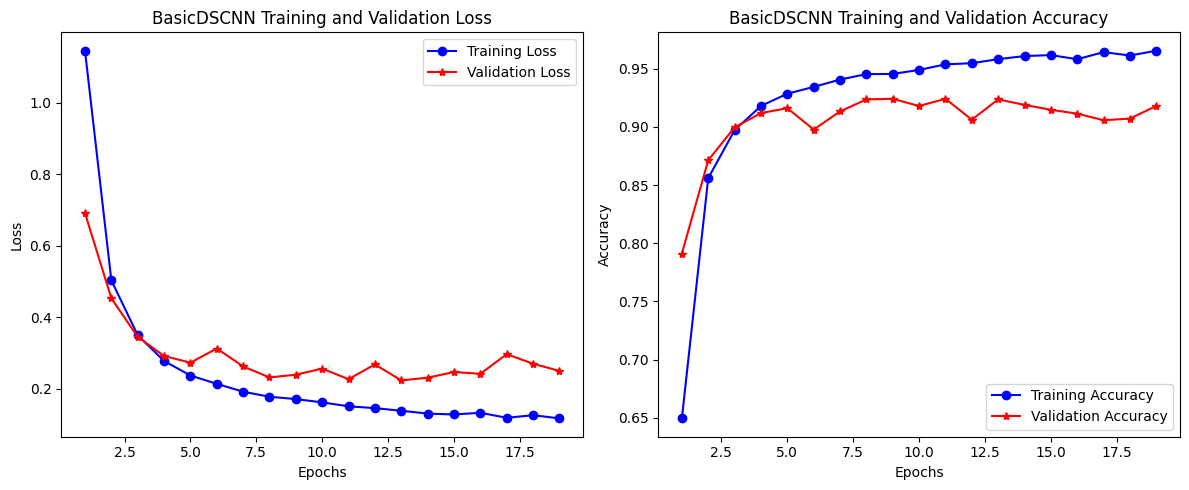

[BasicDSCNN (train)] Loss: 0.1429, Accuracy: 0.9595
[BasicDSCNN (val)] Loss: 0.2397, Accuracy: 0.9241


In [11]:
basic_model = BasicDSCNN(num_classes)
history_basic = train_model(
    basic_model,
    train_loader,
    val_loader,
    num_epochs=150,
    patience=10,
    lr=1e-3,
    weight_decay=1e-3,
    model_name="basic_dscnn"
)

plot_history(history_basic, title_prefix="BasicDSCNN")
best_basic_path = history_basic["best_path"]

_ = evaluate_model(BasicDSCNN, best_basic_path, train_loader, "BasicDSCNN (train)")
_ = evaluate_model(BasicDSCNN, best_basic_path, val_loader,   "BasicDSCNN (val)")


### Confusion matrix & report (BasicDSCNN on val)

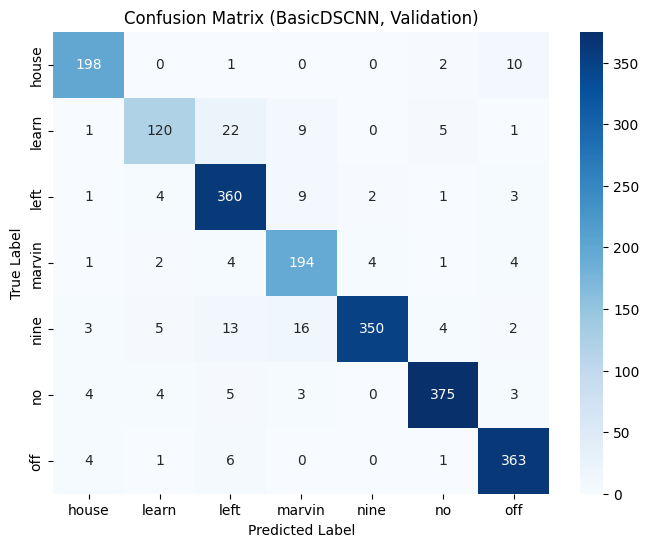

Classification Report (BasicDSCNN, Validation):
              precision    recall  f1-score   support

       house       0.93      0.94      0.94       211
       learn       0.88      0.76      0.82       158
        left       0.88      0.95      0.91       380
      marvin       0.84      0.92      0.88       210
        nine       0.98      0.89      0.93       393
          no       0.96      0.95      0.96       394
         off       0.94      0.97      0.95       375

    accuracy                           0.92      2121
   macro avg       0.92      0.91      0.91      2121
weighted avg       0.93      0.92      0.92      2121



In [12]:
# Load the best improved model 
best_basic_model = BasicDSCNN(num_classes).to(device)
best_basic_model.load_state_dict(torch.load(best_basic_path, map_location=device))
best_basic_model.eval() # Set model to evaluation mode (no dropout, no gradient updates)

all_true_basic = []
all_pred_basic = []
 
with torch.no_grad(): # Disable gradient tracking → faster & memory efficient
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        # Forward
        outputs = best_basic_model(X_batch)
        # Convert network output (logits) to class index using argmax
        _, preds = torch.max(outputs, 1)
        # Collect true and predicted labels
        all_true_basic.extend(y_batch.numpy())
        all_pred_basic.extend(preds.cpu().numpy())

cm_basic = confusion_matrix(all_true_basic, all_pred_basic)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_basic,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (BasicDSCNN, Validation)")
plt.show()

print("Classification Report (BasicDSCNN, Validation):")
print(classification_report(all_true_basic, all_pred_basic,
                            target_names=label_encoder.classes_))


### Train ImprovedDSCNN (second model)

Epoch   1/150 | Train loss: 1.4601, acc: 0.4609 | Val loss: 0.8212, acc: 0.7360
  → New best model saved!
Epoch   2/150 | Train loss: 0.7836, acc: 0.7272 | Val loss: 0.6282, acc: 0.7982
  → New best model saved!
Epoch   3/150 | Train loss: 0.5941, acc: 0.7963 | Val loss: 0.4028, acc: 0.8703
  → New best model saved!
Epoch   4/150 | Train loss: 0.4838, acc: 0.8393 | Val loss: 0.3633, acc: 0.8736
  → New best model saved!
Epoch   5/150 | Train loss: 0.4321, acc: 0.8531 | Val loss: 0.3285, acc: 0.8845
  → New best model saved!
Epoch   6/150 | Train loss: 0.3929, acc: 0.8695 | Val loss: 0.2798, acc: 0.9019
  → New best model saved!
Epoch   7/150 | Train loss: 0.3636, acc: 0.8811 | Val loss: 0.2996, acc: 0.8967
Epoch   8/150 | Train loss: 0.3442, acc: 0.8873 | Val loss: 0.2705, acc: 0.9095
  → New best model saved!
Epoch   9/150 | Train loss: 0.3312, acc: 0.8892 | Val loss: 0.2689, acc: 0.9066
Epoch  10/150 | Train loss: 0.3220, acc: 0.8930 | Val loss: 0.2321, acc: 0.9156
  → New best model

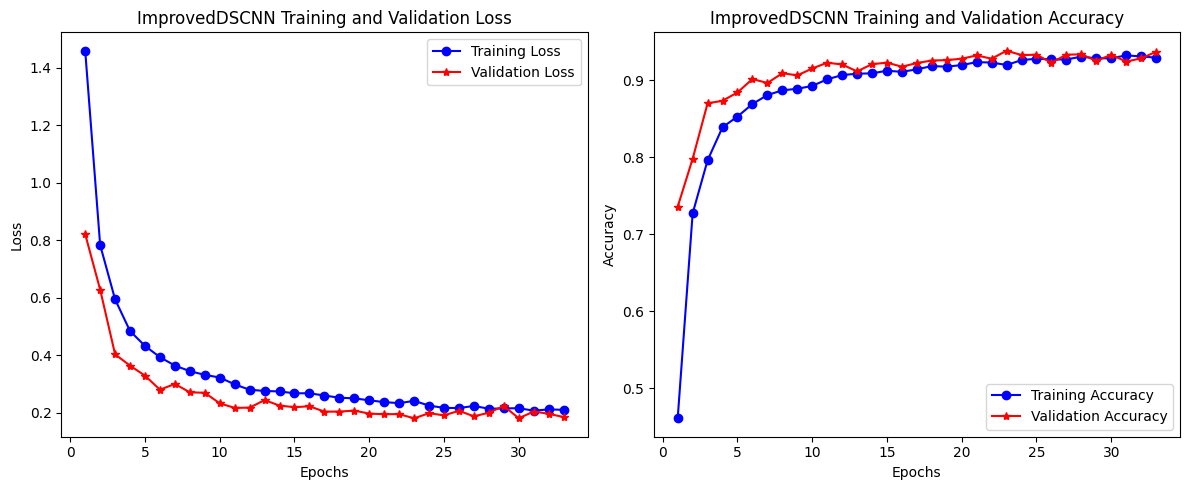

[ImprovedDSCNN (train)] Loss: 0.1261, Accuracy: 0.9615
[ImprovedDSCNN (val)] Loss: 0.1799, Accuracy: 0.9387


In [13]:
improved_model = ImprovedDSCNN(num_classes)
history_improved = train_model(
    improved_model,
    train_loader,
    val_loader,
    num_epochs=150,
    patience=10,
    lr=1e-3,
    weight_decay=1e-3,
    model_name="improved_dscnn"
)

plot_history(history_improved, title_prefix="ImprovedDSCNN")
best_improved_path = history_improved["best_path"]

_ = evaluate_model(ImprovedDSCNN, best_improved_path, train_loader, "ImprovedDSCNN (train)")
_ = evaluate_model(ImprovedDSCNN, best_improved_path, val_loader,   "ImprovedDSCNN (val)")


### Confusion matrix & report (ImprovedDSCNN on val)

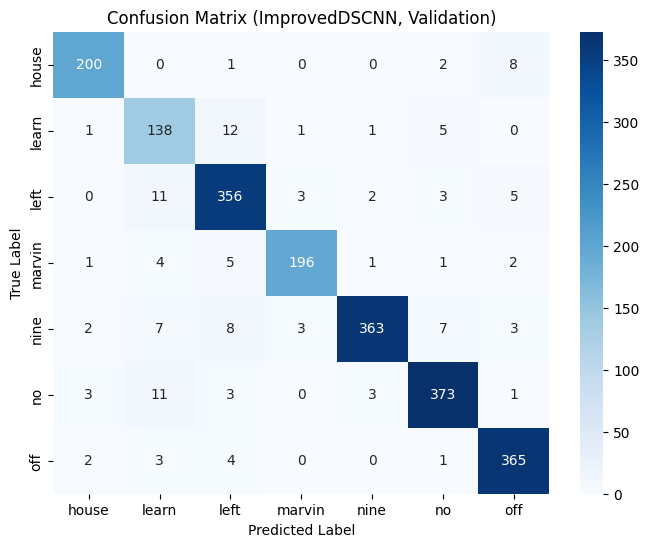

Classification Report (ImprovedDSCNN, Validation):
              precision    recall  f1-score   support

       house       0.96      0.95      0.95       211
       learn       0.79      0.87      0.83       158
        left       0.92      0.94      0.93       380
      marvin       0.97      0.93      0.95       210
        nine       0.98      0.92      0.95       393
          no       0.95      0.95      0.95       394
         off       0.95      0.97      0.96       375

    accuracy                           0.94      2121
   macro avg       0.93      0.93      0.93      2121
weighted avg       0.94      0.94      0.94      2121



In [14]:
# Load the best improved model 
best_improved_model = ImprovedDSCNN(num_classes).to(device)
best_improved_model.load_state_dict(torch.load(best_improved_path, map_location=device))
best_improved_model.eval() # Set model to evaluation mode (no dropout, no gradient updates)

all_true_improved = []
all_pred_improved = []

with torch.no_grad(): # Disable gradient tracking → faster & memory efficient
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        # Forward
        outputs = best_improved_model(X_batch)
        # Convert network output (logits) to class index using argmax
        _, preds = torch.max(outputs, 1)
        # Collect true and predicted labels
        all_true_improved.extend(y_batch.numpy())
        all_pred_improved.extend(preds.cpu().numpy())

cm = confusion_matrix(all_true_improved, all_pred_improved)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (ImprovedDSCNN, Validation)")
plt.show()

print("Classification Report (ImprovedDSCNN, Validation):")
print(classification_report(all_true_improved, all_pred_improved,
                            target_names=label_encoder.classes_))


### Find Misclassified Files

In [ ]:
# Class names we want to inspect
true_label_name = "house"
pred_label_name = "off"

# Convert class names to indices (according to label_encoder)
true_idx = np.where(label_encoder.classes_ == true_label_name)[0][0]
pred_idx = np.where(label_encoder.classes_ == pred_label_name)[0][0]

# Containers for results
mis_rows = []

# Load the best ImprovedDSCNN model
best_model = ImprovedDSCNN(num_classes).to(device)
best_model.load_state_dict(torch.load(best_improved_path, map_location=device))
best_model.eval()

# Global index inside the validation set (to map back to val_filenames)
global_idx = 0

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        outputs = best_model(X_batch)
        # Convert logits to predicted class indices
        _, preds = torch.max(outputs, 1)

        batch_size = y_batch.size(0)
        for i in range(batch_size):
            t = y_batch[i].item()
            p = preds[i].cpu().item()

            # Keep only the specific (true, predicted) pair
            if t == true_idx and p == pred_idx:
                # Map batch index back to the original validation filename
                filename = val_filenames[global_idx + i]
                mis_rows.append({
                    "filename":   filename,
                    "true_label": label_encoder.classes_[t],
                    "pred_label": label_encoder.classes_[p],
                })

        # Move global index by the current batch size
        global_idx += batch_size

# Build a DataFrame for nice display
mis_df = pd.DataFrame(mis_rows, columns=["filename", "true_label", "pred_label"])

print(
    f"Number of misclassified files (true={true_label_name}, "
    f"predicted={pred_label_name}): {len(mis_df)}"
)

# Last line: Jupyter will render this as a nice HTML table
mis_df


Number of misclassified files (true=house, predicted=off): 8


,filename,true_label,pred_label
0,ad6a46f1_nohash_1.wav,house,off
1,e5dadd24_nohash_0.wav,house,off
2,22cb56b3_nohash_0.wav,house,off
3,0cd323ec_nohash_0.wav,house,off
4,a827e3a1_nohash_1.wav,house,off
5,14c7b073_nohash_0.wav,house,off
6,d5dd88da_nohash_0.wav,house,off
7,ab5b211a_nohash_3.wav,house,off
